In [1]:
!wget https://www.dropbox.com/s/nilt43hyl1dx82k/dataset.zip?dl=0

'wget' is not recognized as an internal or external command,
operable program or batch file.


In [2]:
!unzip dataset.zip?dl=0

'unzip' is not recognized as an internal or external command,
operable program or batch file.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
tf.config.run_functions_eagerly(True)  # for debugging (not always recommended for production)
tf.config.experimental_run_functions_eagerly(True)  # older versions


from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.applications.mobilenet import MobileNet, preprocess_input
from tensorflow.keras.losses import categorical_crossentropy


Instructions for updating:
Use `tf.config.run_functions_eagerly` instead of the experimental version.


#  Building our Model To train the data 

In [4]:
# Working with pre trained model 

base_model = MobileNet( input_shape=(224,224,3), include_top= False )

for layer in base_model.layers:
  layer.trainable = False


x = Flatten()(base_model.output)
x = Dense(units=7 , activation='softmax' )(x)

# creating our model.
model = Model(base_model.input, x)

In [5]:
model.compile(optimizer='adam', loss= categorical_crossentropy , metrics=['accuracy']  )

# Preparing our data using data generator

In [6]:
train_datagen = ImageDataGenerator(
     zoom_range = 0.2, 
     shear_range = 0.2, 
     horizontal_flip=True, 
     rescale = 1./255
)

train_data = train_datagen.flow_from_directory(directory= r"C:\Users\prath\OneDrive\Desktop\Emotion-detection-main (1)\train"
, 
                                               target_size=(224,224), 
                                               batch_size=32,
                                  )


train_data.class_indices

Found 350 images belonging to 7 classes.


{'Angry': 0,
 'Disguist': 1,
 'Fear': 2,
 'Happy': 3,
 'Neutral': 4,
 'Sad': 5,
 'Surprise': 6}

In [7]:
val_datagen = ImageDataGenerator(rescale = 1./255 )

val_data = val_datagen.flow_from_directory(directory= r"C:\Users\prath\OneDrive\Desktop\Emotion-detection-main (1)\train", 
                                           target_size=(224,224), 
                                           batch_size=32,
                                  )

Found 350 images belonging to 7 classes.


# visualizaing the data that is fed to train data gen

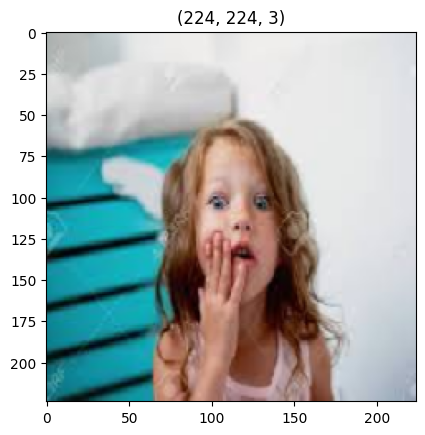

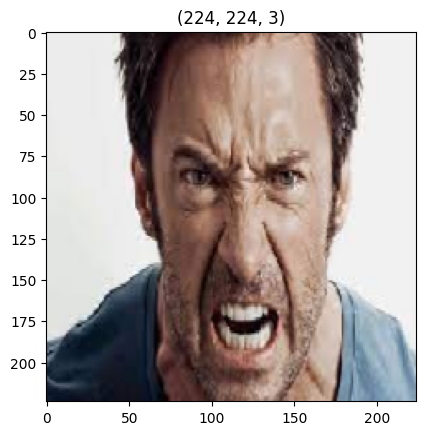

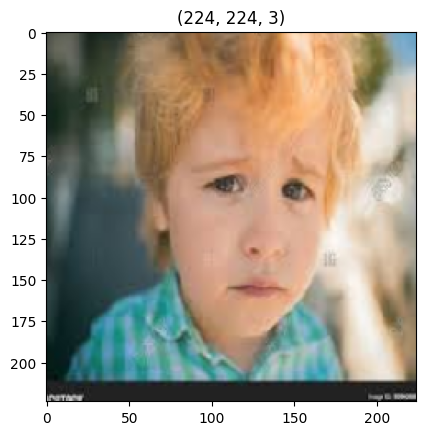

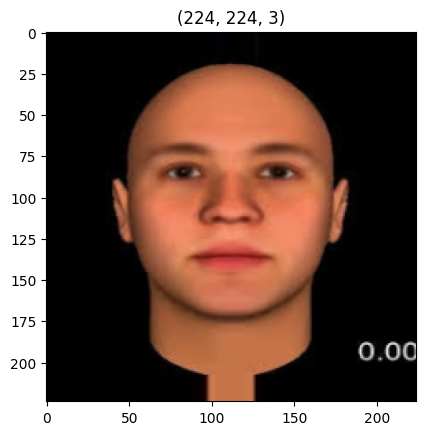

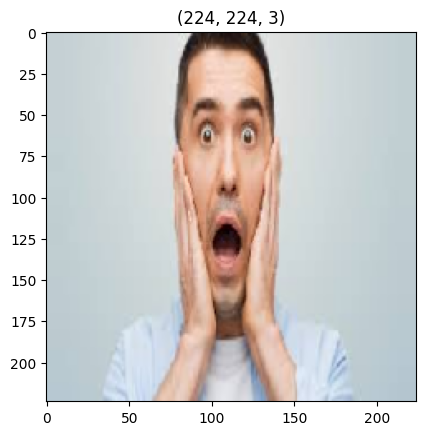

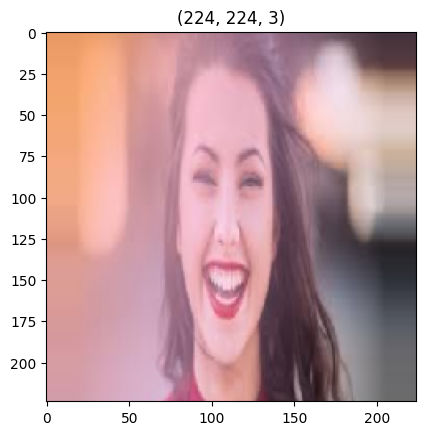

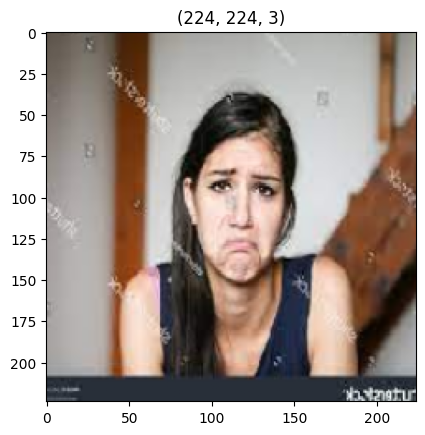

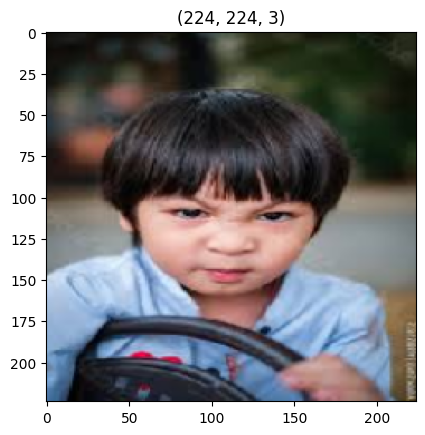

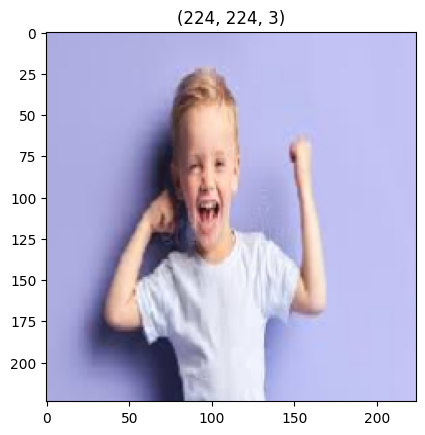

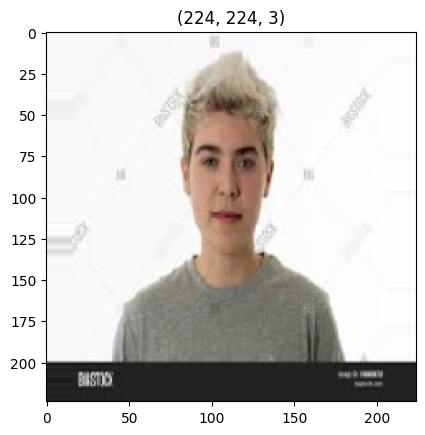

In [8]:
# to visualize the images in the traing data denerator 

t_img , label = next(train_data)


#-----------------------------------------------------------------------------
# function when called will prot the images 
def plotImages(img_arr, label):
  """
  input  :- images array 
  output :- plots the images 
  """
  count = 0
  for im, l in zip(img_arr,label) :
    plt.imshow(im)
    plt.title(im.shape)
    plt.axis = False
    plt.show()
    
    count += 1
    if count == 10:
      break

#-----------------------------------------------------------------------------
# function call to plot the images 
plotImages(t_img, label)

# having early stopping and model check point

In [9]:
## having early stopping and model check point 

from keras.callbacks import ModelCheckpoint, EarlyStopping

# early stopping
es = EarlyStopping(monitor='val_accuracy', min_delta= 0.01 , patience= 5, verbose= 1, mode='auto')

# model check point
mc = ModelCheckpoint(filepath="best_model.h5", monitor= 'val_accuracy', verbose= 1, save_best_only= True, mode = 'auto')

# puting call back in a list 
call_back = [es, mc]

In [11]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

hist=model.fit(train_data, 
          steps_per_epoch=10, 
          epochs=30, 
          validation_data=val_data, 
          validation_steps=8, 
          callbacks=[es, mc])


Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8612 - loss: 0.5950
Epoch 1: val_accuracy did not improve from 0.98828
10/10 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.8616 - loss: 0.6387 - val_accuracy: 0.9727 - val_loss: 0.1179
Epoch 2/30
 1/10 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.8125 - loss: 1.0098
Epoch 2: val_accuracy did not improve from 0.98828
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 601ms/step - accuracy: 0.8125 - loss: 1.0098 - val_accuracy: 0.9609 - val_loss: 0.1750
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9196 - loss: 0.3558
Epoch 3: val_accuracy did not improve from 0.98828
10/10 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.9119 - loss: 0.4880 - val_accuracy: 0.9141 - val_loss: 0.3363
Epoch 4/30
 1/10 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.8750 - loss: 0.8057
Epoch 4: val_accuracy did not improve from 0.98828
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.8750 - loss: 0.8057 - val_accuracy: 0.9805 - val_loss: 0.0920


In [12]:

# Loading the best fit model 
from keras.models import load_model
model = load_model(r"C:\Users\prath\OneDrive\Desktop\Emotion-detection-main (1)\Emotion-detection-main\best_model.h5")

In [13]:
h = hist.history
h.keys()


dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

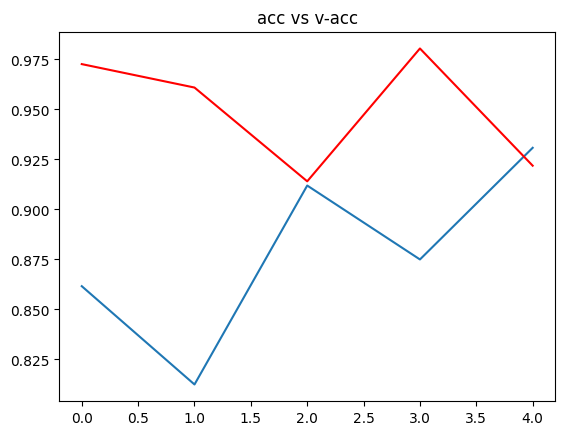

In [14]:
plt.plot(h['accuracy'])
plt.plot(h['val_accuracy'] , c = "red")
plt.title("acc vs v-acc")
plt.show()

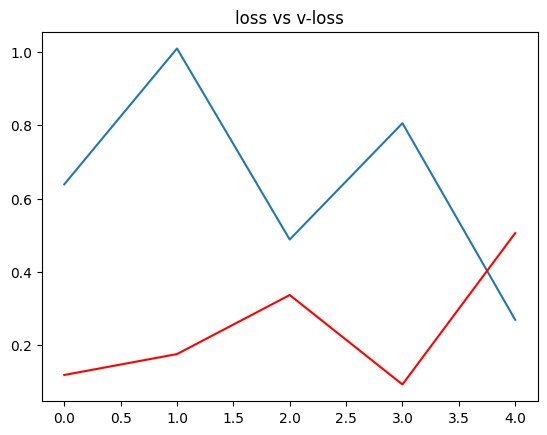

In [15]:
plt.plot(h['loss'])
plt.plot(h['val_loss'] , c = "red")
plt.title("loss vs v-loss")
plt.show()

In [16]:
# just to map o/p values 
op = dict(zip( train_data.class_indices.values(), train_data.class_indices.keys()))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
 the image is of Disguist


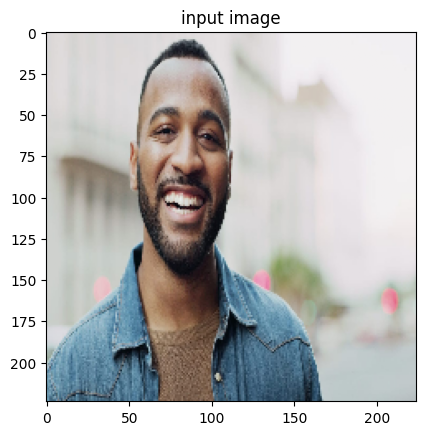

In [17]:
# path for the image to see if it predics correct class

path = r"C:\Users\prath\OneDrive\Desktop\Emotion-detection-main (1)\people.jpg"
img = load_img(path, target_size=(224,224) )

i = img_to_array(img)/255
input_arr = np.array([i])
input_arr.shape

pred = np.argmax(model.predict(input_arr))

print(f" the image is of {op[pred]}")

# to display the image  
plt.imshow(input_arr[0])
plt.title("input image")
plt.show()